# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
    nb_plot_value_functions,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve

In [ ]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 900, 'n_a': 900, 'n_h': 900, 
    },
    calib_overrides={
        't0': 20, 'tau': 0.07
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        nest, grids = solve(
            SYNTAX, method=method,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'extrap_policy' (for cntn_to_dcsn_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for cntn_to_dcsn_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'extrap_policy' (for dcsn_to_arvl_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for dcsn_to_arvl_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving: 100%|██████████| 51/51 [01:00<00:00,  1.19s/it, age=20, avg_adj_ms=22, avg_keeper_ms=215]

NEGM(FUES)



    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'extrap_policy' (for cntn_to_dcsn_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for cntn_to_dcsn_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'extrap_policy' (for dcsn_to_arvl_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'clamp_max_factor' (for dcsn_to_arvl_mover.clamp_max_factor) not declared in stage symbols.settings
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving: 100%|██████████| 51/51 [01:03<00:00,  1.24s/it, age=20, avg_adj_ms=47, avg_keeper_ms=242]


  51 periods, ages 20–70
  r=0.045, R=1.045, r_H=0, R_H=1.0, beta=0.945, alpha=0.7, gamma_c=3.5, gamma_h=1.5, kappa=0.06, sigma=0.001, delta=0, tau=0.07, chi=0, theta=1.3498, K=1.3, lambdas=[4.329982, 0.610214, -0.0209832, 0.0003132, -1.72e-06, 0.0199949, 4.76e-05], tau_av=30
  n_a=600, n_h=600, n_w=600, N_wage=4

  Method            Keeper    Adjuster      Tenure     Total
                (ms/period)  (ms/period)  (ms/period)     (sec)
  ────────────────────────────────────────────────────────────
  EGM(FUES)            215          22         729        61
  NEGM(FUES)           242          47         798        63


## 3. Adjuster policies

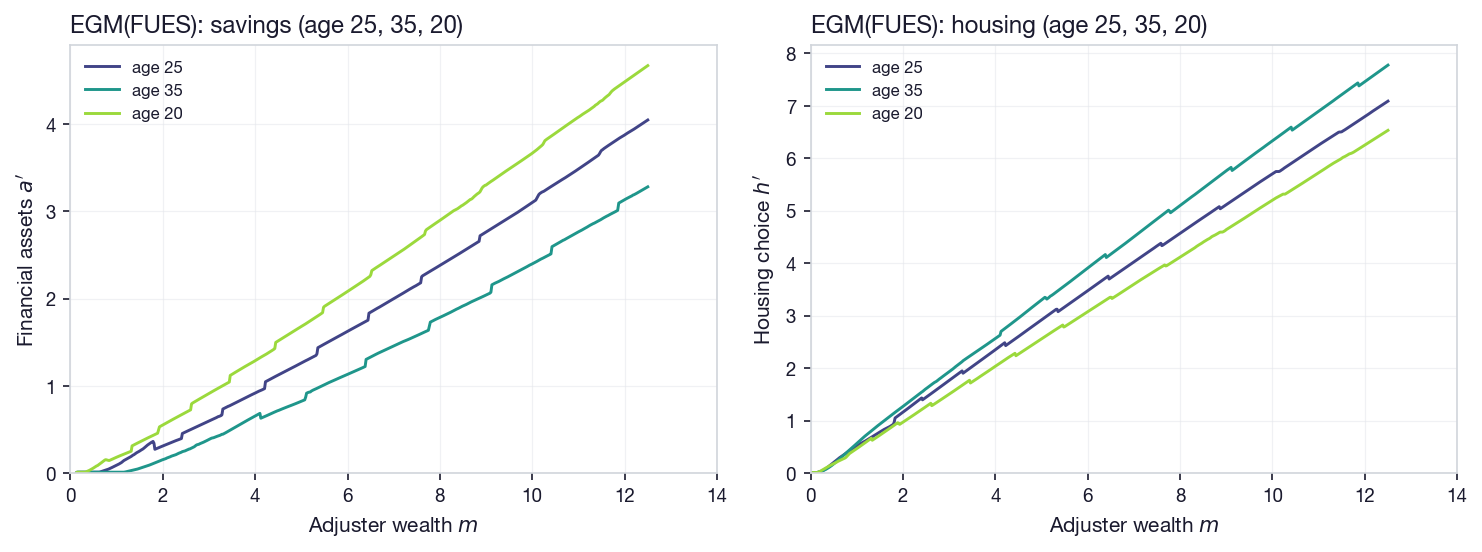

In [3]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[25, 35, 20], methods_filter=['FUES'], i_z=0)

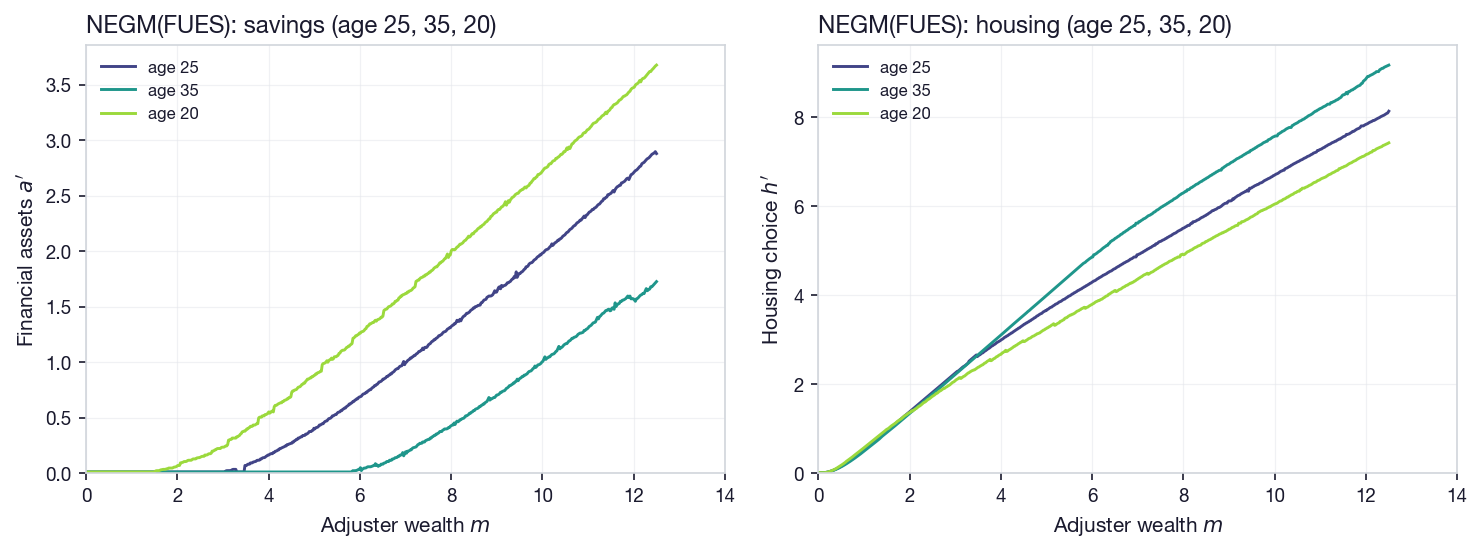

In [4]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[25, 35, 20], methods_filter=['NEGM'], i_z=2)

#fig = nb_plot_value_functions(
#    results, results['FUES']['grids'], plot_t=67)


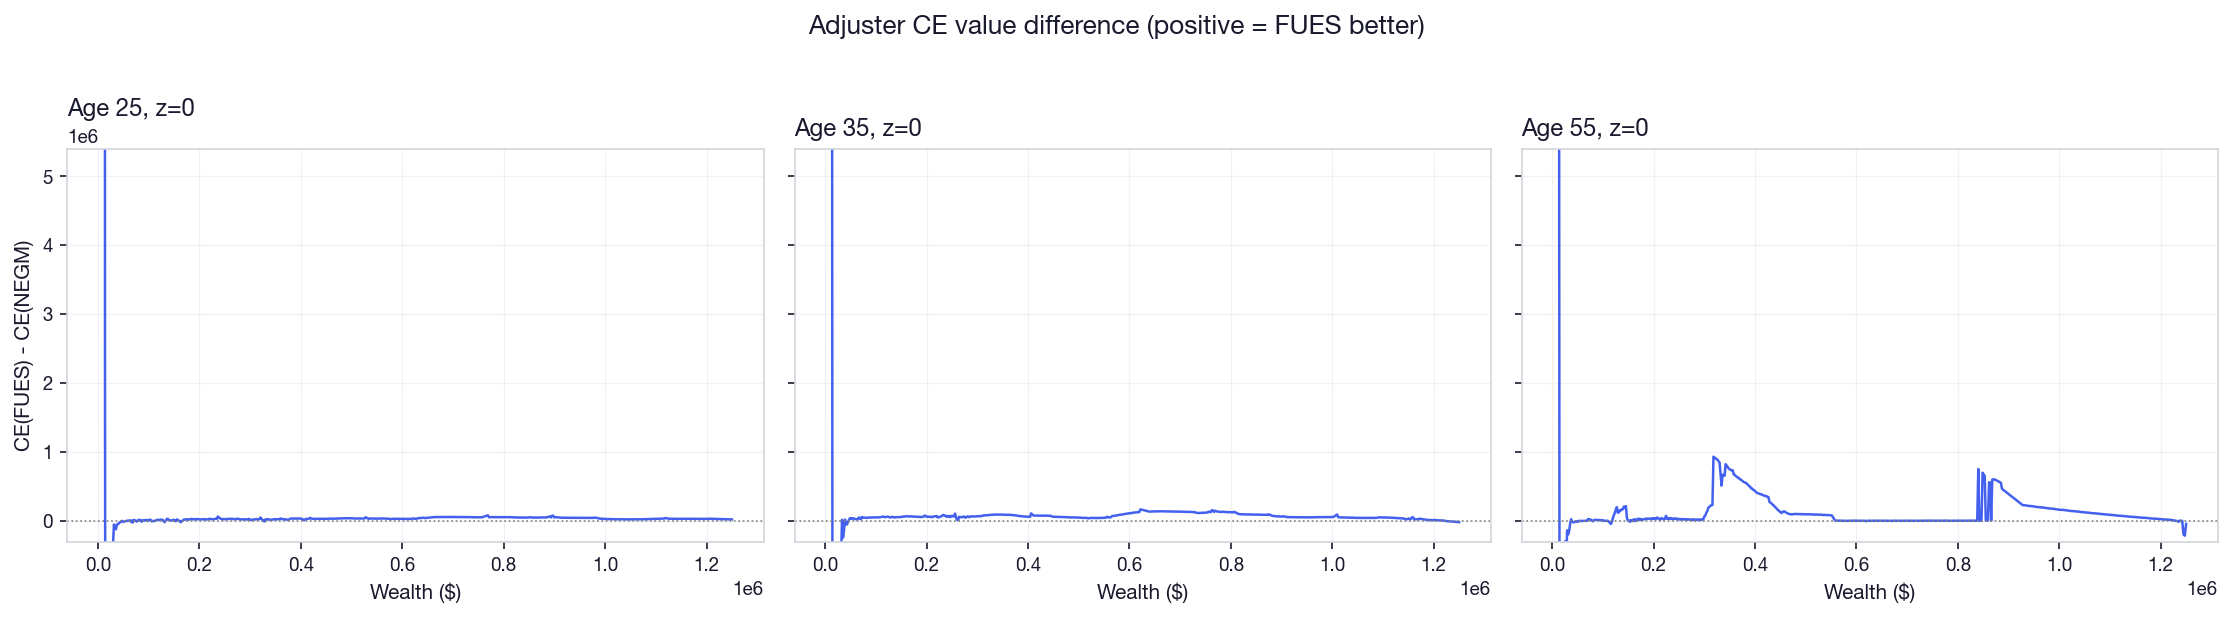

  iw       wealth         V_FUES         V_NEGM           diff
   0     0.020450      -153.2610 -27999999999999995904.0000 27999999999999995904.0000         0.0100
   1     0.039993      -153.2610     -5512.2139      5358.9529         0.0100
   2     0.059539      -153.2610     -1038.2802       885.0192         0.0100
   3     0.079087      -153.2610      -436.2988       283.0378         0.0100
   4     0.098637      -153.2610      -261.4975       108.2366         0.0100
   5     0.118190      -153.2610      -190.7320        37.4710         0.0100
   6     0.137745      -153.2610      -156.1193         2.8583         0.0100
   7     0.157303      -142.4189      -136.3056        -6.1133         0.0131
   8     0.176862      -130.1217      -123.1827        -6.9390         0.0172
   9     0.196425      -117.8231      -113.9637        -3.8594         0.0218
  10     0.215989      -107.5466      -107.1823        -0.3643         0.0271
  11     0.235556      -102.8602      -102.0076        -

In [5]:
# ── CE-transformed adjuster value: FUES vs NEGM difference ──
import matplotlib.pyplot as plt
from examples.durables.outputs.notebook import ce_utility

_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
we = results['FUES']['grids']['we']
sol_f = {s['t']: s for s in results['FUES']['nest']['solutions']}
sol_n = {s['t']: s for s in results['NEGM']['nest']['solutions']}

plot_ages = [25, 35, 55]
iz = 0

def _ce_arr(V):
    """Per-grid-point CE transform."""
    inner = (1.0 - _rho) * V
    return np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm

fig, axes = plt.subplots(1, len(plot_ages), figsize=(5 * len(plot_ages), 4), sharey=True)
for ax, age in zip(axes, plot_ages):
    Vf = sol_f[age]['adjuster_cons']['dcsn']['V'][iz]
    Vn = sol_n[age]['adjuster_cons']['dcsn']['V'][iz]
    ce_f = _ce_arr(Vf)
    ce_n = _ce_arr(Vn)
    diff = ce_f - ce_n

    ax.plot(we * _norm, diff * _norm, lw=1.2, color='#4361ee')
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Wealth ($)')
    ax.set_title(f'Age {age}, z={iz}')
    valid = diff[np.isfinite(diff)]
    if len(valid) > 0:
        ax.set_ylim(np.percentile(valid * _norm, 1), np.percentile(valid * _norm, 99))

axes[0].set_ylabel('CE(FUES) - CE(NEGM)')
fig.suptitle('Adjuster CE value difference (positive = FUES better)', y=1.02)
fig.tight_layout()
plt.show()

we = results['FUES']['grids']['we']                                                                                                                                                                
sol_f = {s['t']: s for s in results['FUES']['nest']['solutions']}                                                                                                                                  
sol_n = {s['t']: s for s in results['NEGM']['nest']['solutions']}                                                                                                                                  
                                                        
age = 35                                                                                                                                                                                           
iz = 0                                                    
Vf = sol_f[age]['adjuster_cons']['dcsn']['V'][iz]                                                                                                                                                  
Vn = sol_n[age]['adjuster_cons']['dcsn']['V'][iz]        
Hn = sol_n[age]['adjuster_cons']['dcsn']['h_choice'][iz]  
                                                                                                                                                                                                    
print(f"{'iw':>4s} {'wealth':>12s} {'V_FUES':>14s} {'V_NEGM':>14s} {'diff':>14s}")                                                                                                                 
for iw in range(20):                                                                                                                                                                               
    print(f"{iw:4d} {we[iw]:12.6f} {Vf[iw]:14.4f} {Vn[iw]:14.4f} {Vf[iw]-Vn[iw]:14.4f} {Hn[iw]:14.4f}") 


age = 35                                                  
iz = 0                                                                                                                                                                                             
cntn = sol_f[age]['adjuster_cons'].get('cntn')            
if cntn:
    refined = cntn.get('_refined', {})
    r = refined.get(iz)
    if r:
        m = r['m_endog']                                                                                                                                                                           
        v = r['vf']
        h = r['h_nxt_eval']                                                                                                                                                                        
        # Show points in the desert region (m < 0.3)                                                                                                                                               
        mask = m < 0.3
        print(f"FUES points with m < 0.3 ({np.sum(mask)} of {len(m)}):")                                                                                                                           
        for i in np.where(mask)[0]:                                                                                                                                                                
            print(f"  m={m[i]:.6f}  V={v[i]:.2f}  h={h[i]:.6f}")  


# V diff across all ages and z, weighted by where agents actually are                                                                                                                              
we = grids['we']                                                                                                                                                                                   
total_diff = np.zeros(len(we))                                                                                                                                                                     
count = 0                                                                                                                                                                                          
for age in range(20, 70):                                 
    if age not in sol_f or age not in sol_n:                                                                                                                                                       
        continue                                                                                                                                                                                   
    Vf = sol_f[age]['adjuster_cons']['dcsn']['V']
    Vn = sol_n[age]['adjuster_cons']['dcsn']['V']                                                                                                                                                  
    for iz in range(Vf.shape[0]):                                                                                                                                                                  
        diff = Vf[iz] - Vn[iz]                                                                                                                                                                     
        diff[np.isinf(diff) | np.isnan(diff)] = 0                                                                                                                                                  
        total_diff += diff                                                                                                                                                                         
        count += 1
                                                                                                                                                                                                    
mean_diff = total_diff / count                            
print(f"Mean V diff (FUES-NEGM) across all ages/z:")                                                                                                                                               
print(f"  Overall mean: {np.mean(mean_diff):.4f}")                                                                                                                                                 
print(f"  Points where FUES wins: {np.sum(mean_diff > 0)}/{len(we)}")
print(f"  Points where NEGM wins: {np.sum(mean_diff < 0)}/{len(we)}")                                                                                                                              
print(f"  Worst FUES loss: {np.min(mean_diff):.4f} at w={we[np.argmin(mean_diff)]:.4f}")


# Count grid points where tenure choice differs                                                                                                                                                    
n_diff = 0                                                
n_total = 0                                                                                                                                                                                        
for age in range(20, 70):
    if age not in sol_f or age not in sol_n:                                                                                                                                                       
        continue                                          
    adj_f = sol_f[age]['tenure']['dcsn']['adj']                                                                                                                                                    
    adj_n = sol_n[age]['tenure']['dcsn']['adj']                                                                                                                                                    
    diff = (np.round(adj_f) != np.round(adj_n))                                                                                                                                                    
    n_diff += np.sum(diff)                                                                                                                                                                         
    n_total += diff.size                                                                                                                                                                           
                                                        
print(f"Tenure adj/keep disagree: {n_diff}/{n_total} = {100*n_diff/n_total:.2f}%")


# Which direction do the flips go?                                                                                                                                                                 
fues_adj_negm_keep = 0                                                                                                                                                                             
fues_keep_negm_adj = 0                                                                                                                                                                             
for age in range(20, 70):                                                                                                                                                                          
    if age not in sol_f or age not in sol_n:                                                                                                                                                       
        continue                                                                                                                                                                                   
    adj_f = np.round(sol_f[age]['tenure']['dcsn']['adj'])
    adj_n = np.round(sol_n[age]['tenure']['dcsn']['adj'])                                                                                                                                          
    fues_adj_negm_keep += np.sum((adj_f == 1) & (adj_n == 0))
    fues_keep_negm_adj += np.sum((adj_f == 0) & (adj_n == 1))                                                                                                                                      
                                                                                                                                                                                                    
print(f"FUES=adjust, NEGM=keep: {fues_adj_negm_keep}")                                                                                                                                             
print(f"FUES=keep, NEGM=adjust: {fues_keep_negm_adj}")                                                                                                                                             
print(f"Net: NEGM adjusts {fues_keep_negm_adj - fues_adj_negm_keep} more states") 


a_grid = grids['a']                                       
h_grid = grids['h']                                                                                                                                                                                
flip_a = []
flip_h = []                                                                                                                                                                                        
for age in [30, 40, 50]:                                  
    if age not in sol_f:                                                                                                                                                                           
        continue
    adj_f = np.round(sol_f[age]['tenure']['dcsn']['adj'])                                                                                                                                          
    adj_n = np.round(sol_n[age]['tenure']['dcsn']['adj']) 
    mask = (adj_f == 0) & (adj_n == 1)                                                                                                                                                             
    for iz in range(mask.shape[0]):
        ia, ih = np.where(mask[iz])                                                                                                                                                                
        flip_a.extend(a_grid[ia])                         
        flip_h.extend(h_grid[ih])                                                                                                                                                                  
                                                                                                                                                                                                    
flip_a = np.array(flip_a)
flip_h = np.array(flip_h)                                                                                                                                                                          
print(f"FUES=keep, NEGM=adjust flips at ages 30,40,50:")  
print(f"  a: mean={flip_a.mean():.3f}, median={np.median(flip_a):.3f}, "                                                                                                                           
    f"p10={np.percentile(flip_a,10):.3f}, p90={np.percentile(flip_a,90):.3f}")                                                                                                                   
print(f"  h: mean={flip_h.mean():.3f}, median={np.median(flip_h):.3f}, "                                                                                                                           
    f"p10={np.percentile(flip_h,10):.3f}, p90={np.percentile(flip_h,90):.3f}") 



from examples.durables.mod.separable.callables import _u                                                                                                                                           
cal = results['FUES']['nest']['periods'][0]['stages']['keeper_cons'].calibration                                                                                                                   
alpha = float(cal['alpha'])                                                                                                                                                                        
gc = float(cal['gamma_c'])                                                                                                                                                                         
gh = float(cal['gamma_h'])                                                                                                                                                                         
kappa = float(cal['kappa'])                               
chi = float(cal['chi'])                                                                                                                                                                            
                                                        
age = 35                                                                                                                                                                                           
iz = 0                                                    
Cf = sol_f[age]['adjuster_cons']['dcsn']['c'][iz]                                                                                                                                                  
Hf = sol_f[age]['adjuster_cons']['dcsn']['h_choice'][iz]                                                                                                                                           
Cn = sol_n[age]['adjuster_cons']['dcsn']['c'][iz]                                                                                                                                                  
Hn = sol_n[age]['adjuster_cons']['dcsn']['h_choice'][iz]                                                                                                                                           
Vf = sol_f[age]['adjuster_cons']['dcsn']['V'][iz]         
Vn = sol_n[age]['adjuster_cons']['dcsn']['V'][iz]                                                                                                                                                  
                                                        
print(f"{'iw':>4s} {'w':>8s} {'u_FUES':>10s} {'u_NEGM':>10s} {'u_diff':>10s} {'V_diff':>10s}")                                                                                                     
for iw in range(20):                                      
    w = we[iw]                                                                                                                                                                                     
    uf = _u(Cf[iw], Hf[iw], chi, alpha, gc, gh, kappa)                                                                                                                                             
    un = _u(Cn[iw], Hn[iw], chi, alpha, gc, gh, kappa)                                                                                                                                             
    vdiff = Vf[iw] - Vn[iw]                                                                                                                                                                        
    print(f"{iw:4d} {w:8.4f} {uf:10.4f} {un:10.4f} {uf-un:10.4f} {vdiff:10.4f}")                                                                                                                   
                                                                                                                                                                                                    
cntn = sol_f[35]['adjuster_cons'].get('cntn')                                                                                                                                                      
if cntn:                                                                                                                                                                                           
    r = cntn['_refined'][0]
    print(f"m_clean[0] = {r['m_endog'][0]:.6f}")                                                                                                                                                   
    print(f"we_grid[0] = {we[0]:.6f}")                                                                                                                                                             
    print(f"we_grid[6] = {we[6]:.6f}")                                                                                                                                                             
                                        
                                                            


## 4. Adjuster EGM grid

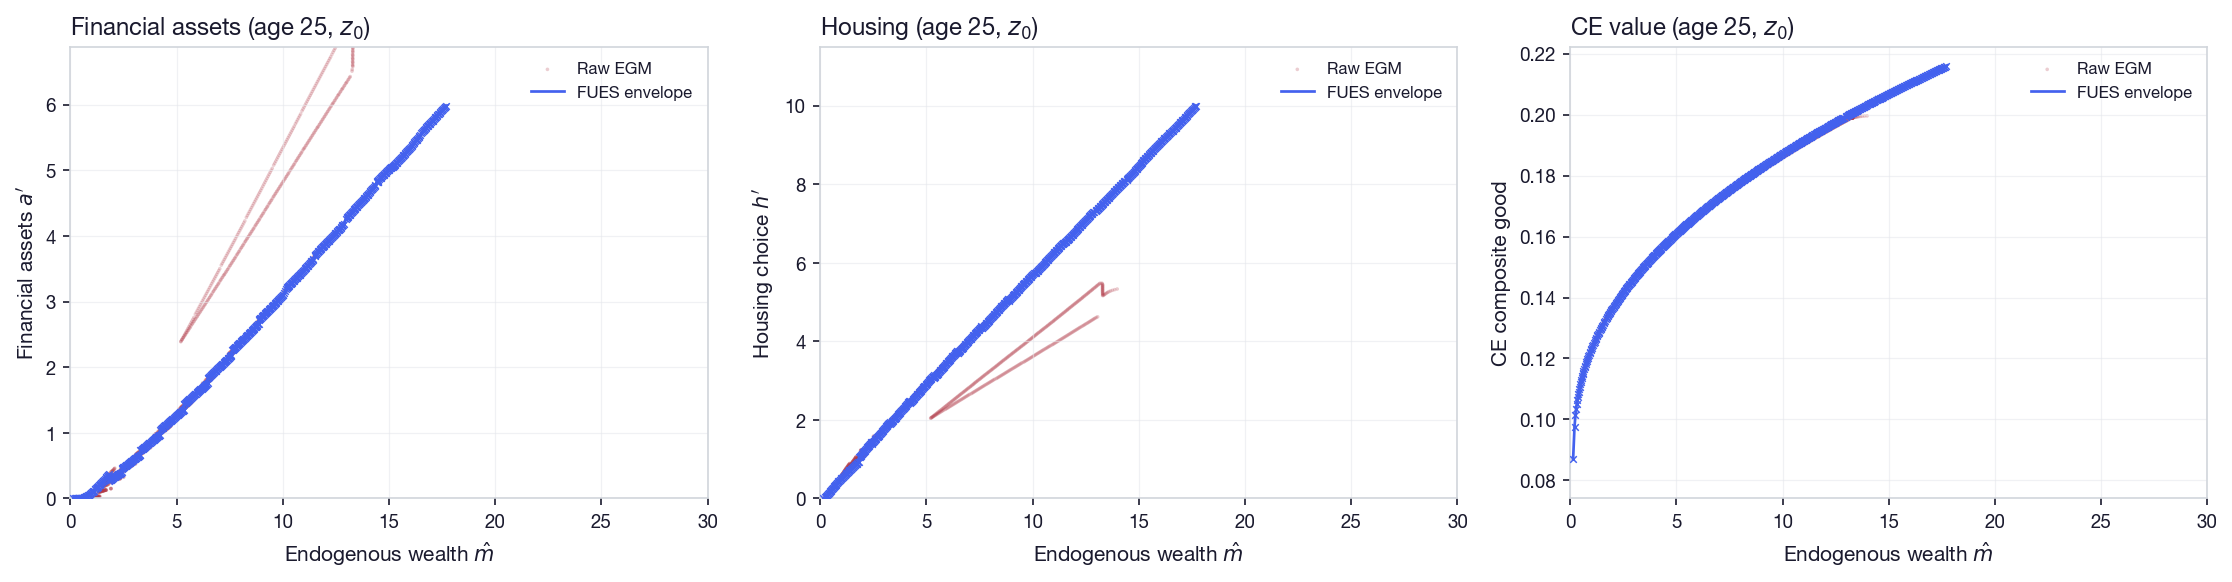

In [6]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=25, xlim =30, i_z=0)

In [7]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=42, i_z=0)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

  age 25, z=0: m_clean[0]=0.138621, len=631
  age 25, z=1: m_clean[0]=0.140113, len=598
  age 35, z=0: m_clean[0]=0.140057, len=635
  age 35, z=1: m_clean[0]=0.140762, len=599
  age 55, z=0: m_clean[0]=0.139881, len=561
  age 55, z=1: m_clean[0]=0.140606, len=569


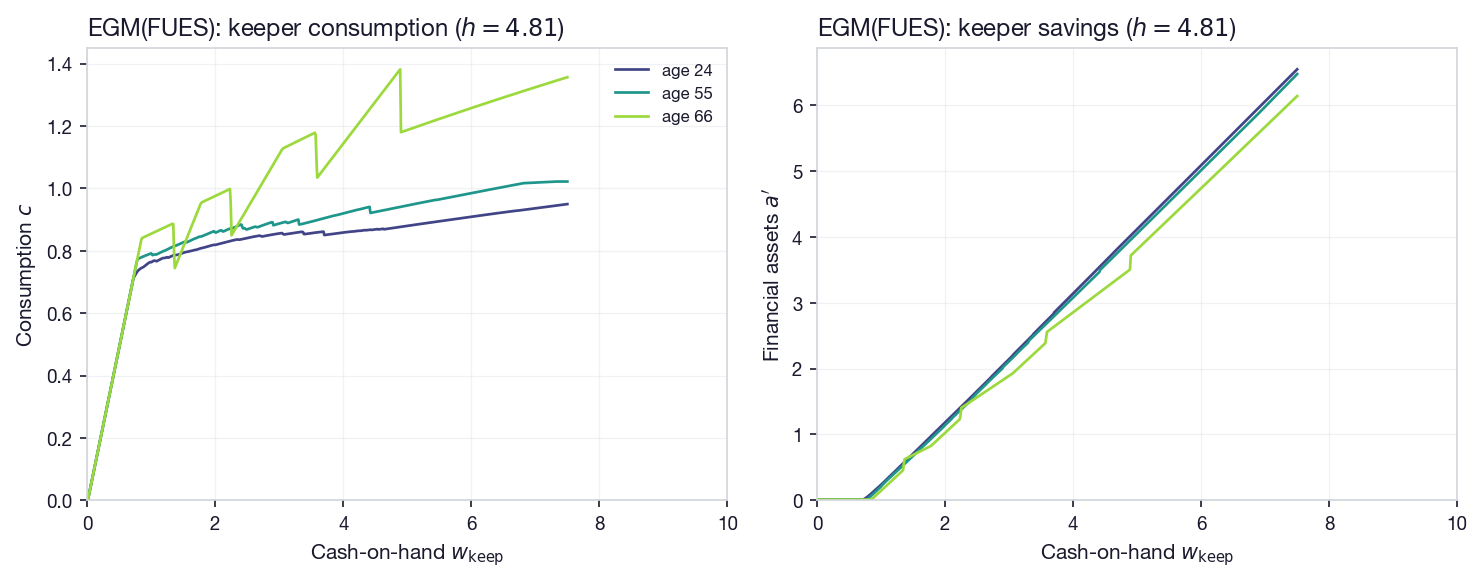

In [8]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['FUES'], xlim=10, i_z=3)
sol_f = {s['t']: s for s in results['FUES']['nest']['solutions']}                                                                                                                                  
for age in [25, 35, 55]:                                                                                                                                                                           
    ref = sol_f[age]['adjuster_cons'].get('cntn', {})
    for iz in range(min(2, len(grids['z']))):                                                                                                                                                      
        r = ref.get('_refined', {}).get(iz)               
        if r is not None:                                                                                                                                                                          
            print(f"  age {age}, z={iz}: m_clean[0]={r['m_endog'][0]:.6f}, "
                f"len={len(r['m_endog'])}")

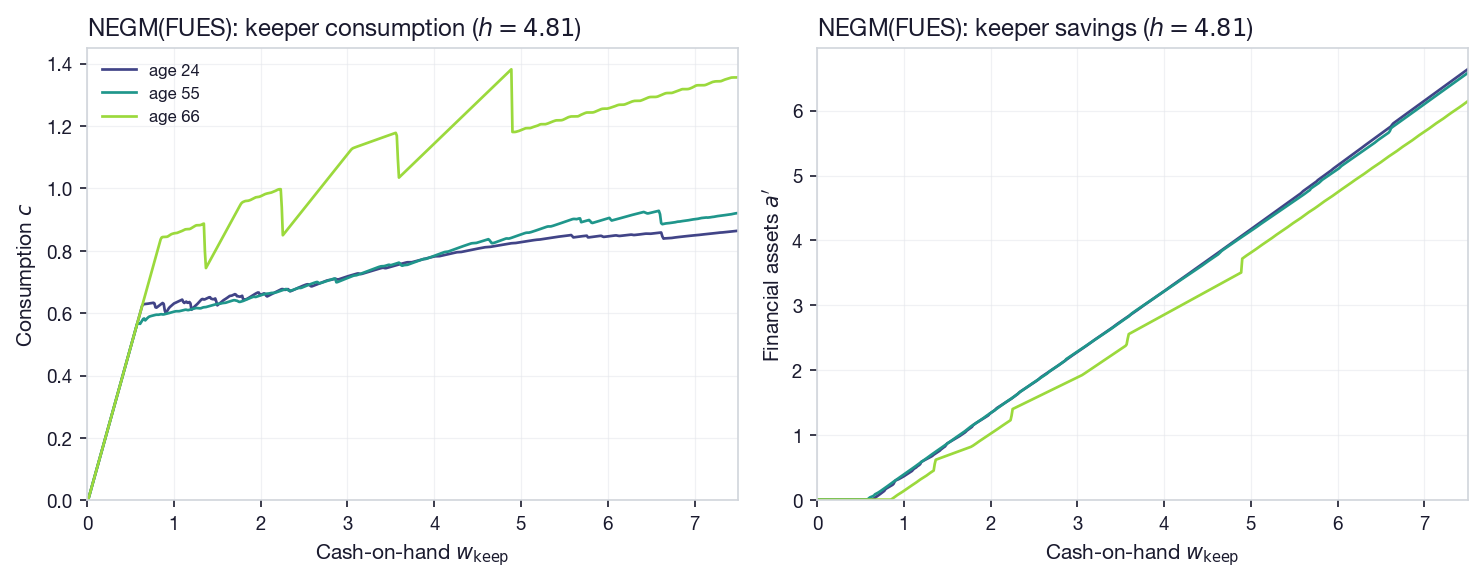

In [9]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['NEGM'])

## 6. Euler equation errors

In [10]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=21, init_dispersion=2)       
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


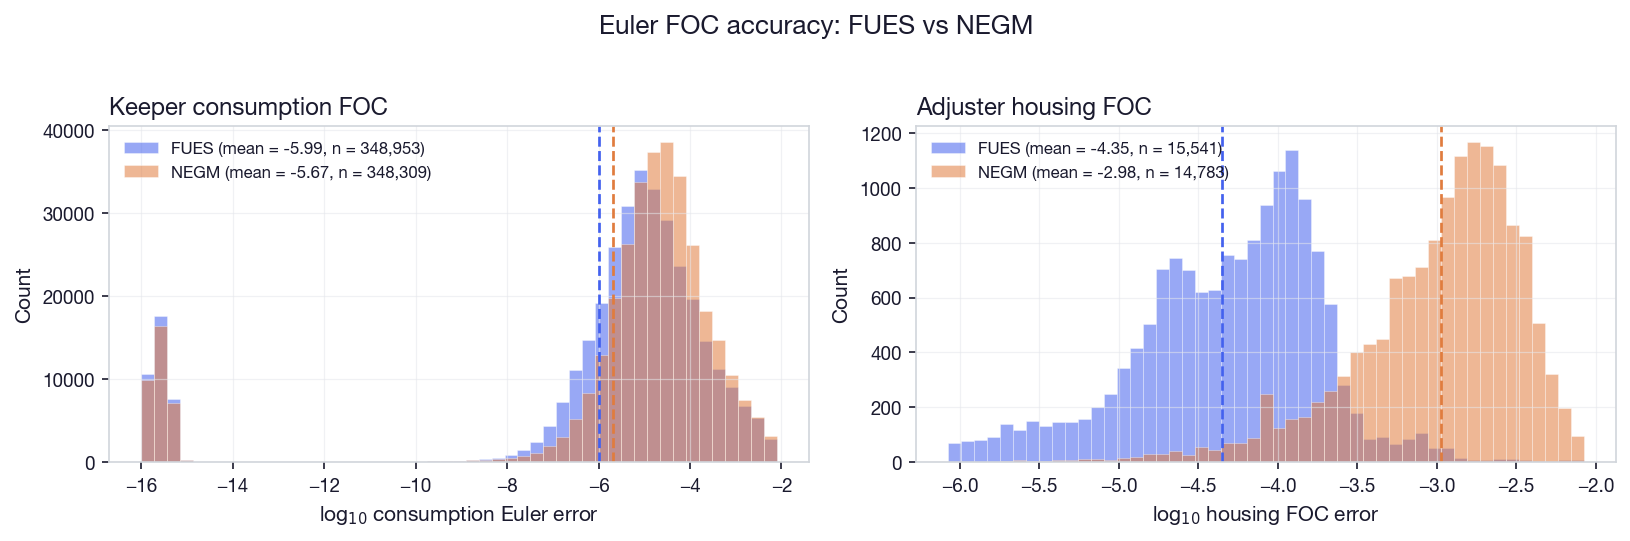

In [11]:
fig = plot_euler_histogram(euler_results)

In [12]:
# ── Per-agent CE utility histogram ──
import matplotlib.pyplot as plt

_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data']['npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(ce, bins=80, alpha=0.5, label=_labels[method], color=_colors[method])
    ax.axvline(np.median(ce), color=_colors[method], ls='--', lw=1.2,
               label=f'{_labels[method]} median: {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Comparison of aggregates

In [14]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))




### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 215 | 242 |
| Adjuster (ms/period) | 22 | 47 |
| Total (ms/period) | 965 | 1087 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -5.99 | -5.67 |
| Consumption: adjuster | -11.42 | -10.65 |
| Consumption: all | -6.22 | -5.88 |
| Housing: adjuster | -4.35 | -2.98 |
| **Simulation** |  |  |
| CE utility | 17,057.89 | 17,082.88 |
| Mean consumption ($) | 62,210 | 62,199 |
| Mean fin. assets ($) | 68,918 | 68,654 |
| Mean housing ($) | 249,644 | 249,966 |
| Adjustment rate (%) | 19.3 | 19.6 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


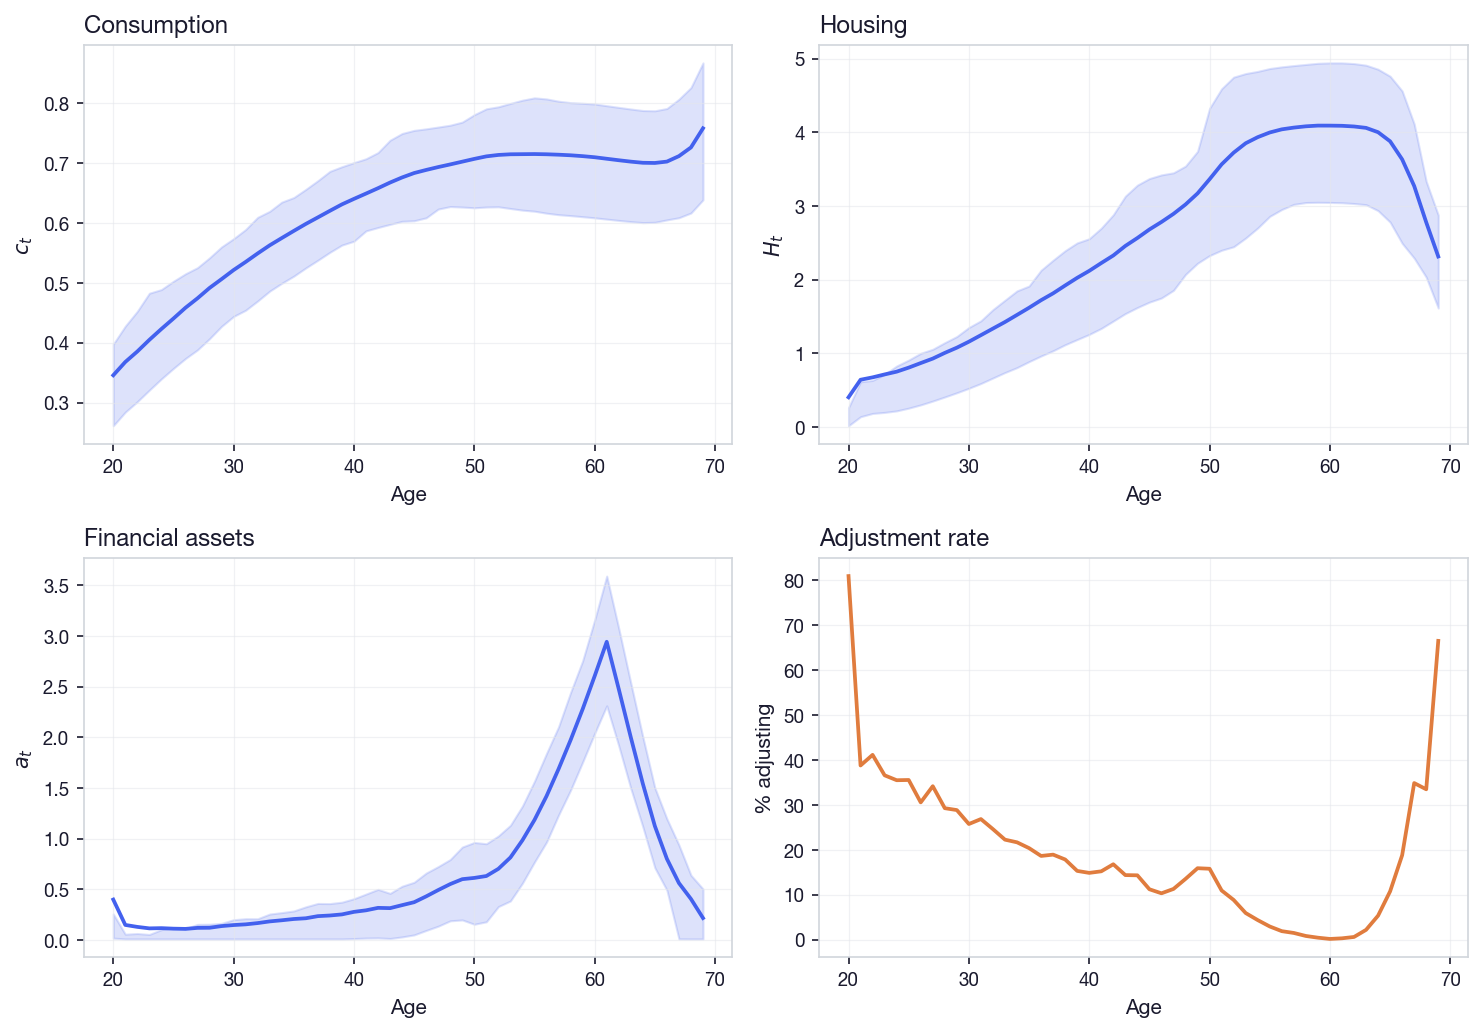

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


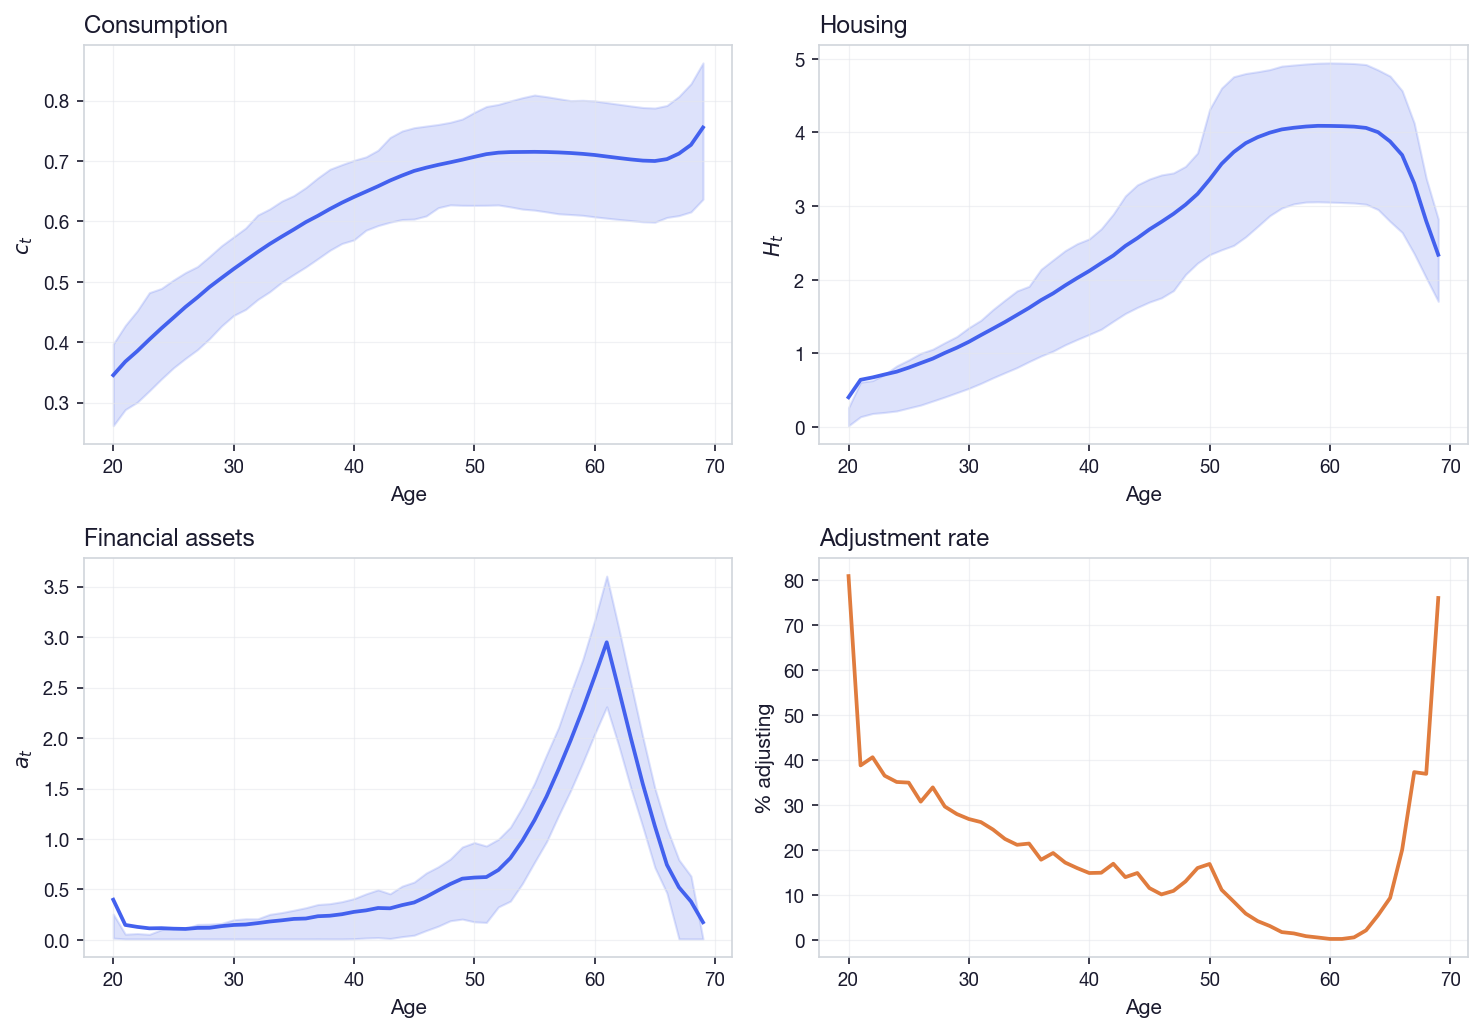

In [15]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [16]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 38,527.42 | 12,198.06 | 18,138.34 | 59,300.83 | 63,752.06 | 104,553.84 |
| 25–29 | 47,417.60 | 10,738.62 | 11,940.59 | 23,975.00 | 93,783.98 | 96,692.33 |
| 30–34 | 54,870.26 | 9,910.06 | 16,904.18 | 23,387.91 | 133,814.39 | 96,179.60 |
| 35–39 | 60,932.85 | 9,615.36 | 22,991.70 | 27,630.10 | 182,052.14 | 101,890.33 |
| 40–44 | 65,841.78 | 9,672.42 | 30,886.64 | 34,585.73 | 233,949.63 | 112,072.77 |
| 45–49 | 69,335.87 | 10,062.42 | 48,943.47 | 45,964.40 | 290,974.27 | 125,969.23 |
| 50–54 | 71,256.93 | 11,204.25 | 74,896.82 | 57,237.75 | 368,761.38 | 142,384.28 |
| 55–59 | 71,397.09 | 12,551.00 | 170,914.93 | 79,321.32 | 405,475.08 | 143,686.72 |
| 60–64 | 70,521.14 | 12,849.36 | 231,408.48 | 96,015.61 | 406,384.99 | 143,844.29 |
| 65–69 | 72,000.13 | 13,950.00 | 62,153.62 | 55,039.63 | 317,490.41 | 134,346.99 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 38,525.34 | 12,202.52 | 18,176.24 | 59,316.97 | 63,729.15 | 104,525.85 |
| 25–29 | 47,422.73 | 10,734.37 | 11,948.96 | 23,992.59 | 93,801.23 | 96,659.37 |
| 30–34 | 54,867.87 | 9,913.89 | 16,904.11 | 23,420.59 | 133,837.09 | 96,137.92 |
| 35–39 | 60,927.66 | 9,623.93 | 23,015.39 | 27,637.65 | 182,067.37 | 101,901.71 |
| 40–44 | 65,835.09 | 9,670.30 | 30,926.29 | 34,626.81 | 233,967.53 | 112,136.61 |
| 45–49 | 69,325.14 | 10,062.21 | 49,016.39 | 46,062.55 | 290,973.29 | 125,858.58 |
| 50–54 | 71,236.25 | 11,192.15 | 74,605.30 | 57,262.59 | 369,162.84 | 142,114.69 |
| 55–59 | 71,387.29 | 12,553.58 | 171,157.78 | 79,141.96 | 405,438.07 | 143,696.86 |
| 60–64 | 70,512.99 | 12,861.81 | 231,762.24 | 95,759.36 | 406,354.16 | 143,681.47 |
| 65–69 | 71,950.87 | 13,963.39 | 59,023.48 | 54,578.75 | 320,332.19 | 132,680.10 |